In [15]:
# For developments outside of the controlgym working directory: use pip install controlgym==1.0.0 to install the package
import numpy as np
import controlgym as gym
import time

In [22]:
LINEAR_PDE_IDS = {"convection_diffusion_reaction", "wave", "schrodinger"}
VALID_CTRL_MODES = {"lqg", "lqr"}
DATASET_MODES = ("zero", "random", "ctrl")
DEFAULT_RANDOM_SIGNAL_KWARGS = {
    "signal_mode": "manual",
    "freq_range": (1, 3),
    "min_val": -1.0,
    "max_val": 1.0,
    "amp_range": (10, 20),
}
DEFAULT_RUN_CONFIG = {
    "ctrl_mode": "lqg",
    "dataset_modes": list(DATASET_MODES),
    "init_seed": 123,
    "noise_seed": 10_000,
    "sample_check_count": 5,
    "sample_check_seed": 42,
    "fill_nan": False,
    "output_dir": ".",
    "env_kwargs": {},
    "random_signal_kwargs": {
        "signal_mode": "manual",
        "freq_range": [1, 3],
        "min_val": -1.0,
        "max_val": 1.0,
        "amp_range": [10, 20],
        "num_modes": 4,
        "zero_mean": True,
        "per_dim": True,
    },
}

ENV_ARG_KEYS = (
    "n_steps",
    "domain_length",
    "integration_time",
    "sample_time",
    "process_noise_cov",
    "sensor_noise_cov",
    "n_state",
    "n_observation",
    "n_action",
    "control_sup_width",
    "Q_weight",
    "R_weight",
    "action_limit",
    "observation_limit",
    "reward_limit",
)

RANDOM_ARG_MAP = {
    "signal_mode": "random_signal_mode",
    "freq_range": "random_freq_range",
    "min_val": "random_min_val",
    "max_val": "random_max_val",
    "amp_range": "random_amp_range",
    "cycles_range": "random_cycles_range",
    "num_modes": "random_num_modes",
    "zero_mean": "random_zero_mean",
    "per_dim": "random_per_dim",
}


def _is_2d_array(x) -> bool:
    """Return True if x is a NumPy matrix-like 2D array."""
    return isinstance(x, np.ndarray) and x.ndim == 2


def _validate_dataset_modes(dataset_modes) -> tuple[str, ...]:
    dataset_modes = DATASET_MODES if dataset_modes is None else tuple(dataset_modes)
    if len(dataset_modes) == 0:
        raise ValueError("dataset_modes must contain at least one mode.")
    if len(set(dataset_modes)) != len(dataset_modes):
        raise ValueError("dataset_modes contains duplicate modes.")
    unknown = set(dataset_modes) - set(DATASET_MODES)
    if unknown:
        raise ValueError(f"Unknown dataset modes: {unknown}. Allowed: {DATASET_MODES}")
    return dataset_modes


def _validate_inputs(
    env_id: str,
    ctrl_mode: str,
    n_traj: int,
    dataset_modes,
) -> tuple[str, ...]:
    if env_id not in LINEAR_PDE_IDS:
        raise ValueError(
            f"{env_id} is nonlinear in controlgym. LQG/LQR are supported only for {LINEAR_PDE_IDS}."
        )
    if n_traj <= 0:
        raise ValueError("n_traj must be a positive integer.")
    dataset_modes = _validate_dataset_modes(dataset_modes)
    if "ctrl" in dataset_modes and ctrl_mode not in VALID_CTRL_MODES:
        raise ValueError("ctrl_mode must be 'lqg' or 'lqr' when 'ctrl' is requested.")
    return dataset_modes


def _make_envs(env_id: str, dataset_modes, **env_kwargs):
    env_init = gym.make(env_id, **env_kwargs)
    envs = {mode: gym.make(env_id, **env_kwargs) for mode in dataset_modes}
    return env_init, envs


def _resolve_random_signal_kwargs(random_signal_kwargs: dict | None) -> dict:
    resolved = dict(DEFAULT_RANDOM_SIGNAL_KWARGS)
    if random_signal_kwargs is not None:
        resolved.update(dict(random_signal_kwargs))
    resolved.pop("env", None)
    resolved.pop("seed", None)
    return resolved


def _make_controllers(
    envs,
    dataset_modes,
    ctrl_mode: str,
    random_signal_kwargs: dict,
):
    controllers = {}

    if "zero" in dataset_modes:
        controllers["zero"] = gym.controllers.Zero(envs["zero"])

    if "random" in dataset_modes:
        controllers["random"] = gym.controllers.SmoothRandom(
            envs["random"],
            **random_signal_kwargs,
        )

    if "ctrl" in dataset_modes:
        env_ctrl = envs["ctrl"]
        ctrl = gym.controllers.LQG(env_ctrl) if ctrl_mode == "lqg" else gym.controllers.LQR(env_ctrl)
        if ctrl_mode == "lqg":
            if getattr(env_ctrl, "sensor_noise_cov", 0.0) <= 0:
                raise ValueError("LQG requires sensor_noise_cov > 0.")
            if not _is_2d_array(ctrl.gain_lqr):
                raise RuntimeError("LQG gain_lqr is invalid. Try different env/noise settings.")
            if not _is_2d_array(ctrl.gain_kf):
                raise RuntimeError(
                    "LQG gain_kf is invalid (not a matrix). "
                    "Try setting n_observation=n_state and positive process/sensor noise covariances."
                )
        controllers["ctrl"] = ctrl

    return controllers


def _sample_initial_state(env_init, seed: int) -> np.ndarray:
    _, info = env_init.reset(seed=seed)
    return info["state"].copy()


def _extract_shared_b2(*envs) -> np.ndarray:
    b2 = envs[0].B2.copy()
    for env in envs[1:]:
        if not np.allclose(b2, env.B2):
            raise RuntimeError(
                "Expected all requested linear PDE env clones to share the same B2 matrix."
            )
    return b2


def _select_action(mode: str, controller, current_state: np.ndarray, est_state: np.ndarray | None):
    if mode in {"zero", "random"}:
        return controller.select_action()
    if mode == "lqr":
        return controller.select_action(current_state)
    if mode == "lqg":
        return controller.select_action(est_state)
    raise ValueError(f"Unknown mode: {mode}")


def rollout_with_actions(env, controller, mode: str, x0: np.ndarray, noise_seed: int):
    """Run one rollout and return X, U, reward sum, and valid horizon T."""
    if mode == "random":
        controller.reset(seed=noise_seed)

    _, info = env.reset(seed=noise_seed, state=x0)
    current_state = info["state"]

    X = np.full((env.n_state, env.n_steps + 1), np.nan)
    U = np.full((env.n_action, env.n_steps), np.nan)
    X[:, 0] = current_state

    total_reward = 0.0
    est_state = current_state.copy() if mode == "lqg" else None
    use_kf = mode == "lqg" and _is_2d_array(getattr(controller, "gain_kf", None))

    for t in range(env.n_steps):
        u = _select_action(mode, controller, current_state, est_state)
        obs, reward, terminated, truncated, info = env.step(u)

        current_state = info["state"]
        X[:, t + 1] = current_state
        U[:, t] = u
        total_reward += reward

        if terminated or truncated:
            T = t + 1
            return X[:, : T + 1], U[:, : T], total_reward, T

        if mode == "lqg":
            if use_kf:
                est_state = controller.evolve_state_estimate(est_state, u, obs)
            else:
                est_state = current_state.copy()

    return X, U, total_reward, env.n_steps


def _compute_control_field(b2: np.ndarray, U: np.ndarray) -> np.ndarray:
    return b2 @ U


def _allocate_dataset_arrays(
    dataset_modes,
    n_traj: int,
    n_state: int,
    n_action: int,
    n_steps: int,
):
    return {
        "init_states": np.zeros((n_traj, n_state)),
        "X": {
            mode: np.full((n_traj, n_state, n_steps + 1), np.nan)
            for mode in dataset_modes
        },
        "U": {
            mode: np.full((n_traj, n_action, n_steps), np.nan)
            for mode in dataset_modes
        },
        "U_field": {
            mode: np.full((n_traj, n_state, n_steps), np.nan)
            for mode in dataset_modes
        },
        "R": {mode: np.zeros(n_traj) for mode in dataset_modes},
        "T": {mode: np.zeros(n_traj, dtype=int) for mode in dataset_modes},
    }


def _store_one_rollout(data, mode: str, b2: np.ndarray, k: int, X, U, R: float, T: int):
    data["X"][mode][k, :, : X.shape[1]] = X
    data["U"][mode][k, :, : U.shape[1]] = U
    F = _compute_control_field(b2, U)
    data["U_field"][mode][k, :, : F.shape[1]] = F
    data["R"][mode][k] = R
    data["T"][mode][k] = T


def generate_controlled_dataset(
    env_id: str,
    n_traj: int,
    ctrl_mode: str = "lqg",
    dataset_modes=DATASET_MODES,
    init_seed: int = 123,
    noise_seed: int = 10_000,
    random_signal_kwargs: dict | None = None,
    verbose: bool = True,
    **env_kwargs,
):
    """Generate aligned trajectory datasets for the requested rollout modes."""
    dataset_modes = _validate_inputs(env_id, ctrl_mode, n_traj, dataset_modes)
    resolved_random_signal_kwargs = _resolve_random_signal_kwargs(random_signal_kwargs)

    env_init, envs = _make_envs(env_id, dataset_modes, **env_kwargs)
    controllers = _make_controllers(
        envs,
        dataset_modes,
        ctrl_mode,
        resolved_random_signal_kwargs,
    )

    reference_env = next(iter(envs.values()))
    n_state, n_action, n_steps = (
        reference_env.n_state,
        reference_env.n_action,
        reference_env.n_steps,
    )
    out = _allocate_dataset_arrays(dataset_modes, n_traj, n_state, n_action, n_steps)
    b2 = _extract_shared_b2(*tuple(envs.values()))

    out["traj_times_sec"] = np.zeros(n_traj, dtype=np.float64)
    t_global_start = time.perf_counter()

    for k in range(n_traj):
        t0 = time.perf_counter()

        x0 = _sample_initial_state(env_init, seed=init_seed + k)
        out["init_states"][k] = x0

        seed_k = noise_seed + k
        for mode in dataset_modes:
            rollout_mode = ctrl_mode if mode == "ctrl" else mode
            X, U, R, T = rollout_with_actions(
                envs[mode],
                controllers[mode],
                rollout_mode,
                x0,
                seed_k,
            )
            _store_one_rollout(out, mode, b2, k, X, U, R, T)

        dt = time.perf_counter() - t0
        out["traj_times_sec"][k] = dt

        if verbose:
            elapsed = time.perf_counter() - t_global_start
            mean_time = out["traj_times_sec"][: k + 1].mean()
            remaining = mean_time * (n_traj - k - 1)
            print(
                f"[{k + 1}/{n_traj}] traj={dt:.3f}s | "
                f"elapsed={elapsed:.2f}s | "
                f"eta={remaining:.2f}s"
            )

    total_elapsed = time.perf_counter() - t_global_start

    out["env_id"] = env_id
    out["ctrl_mode"] = ctrl_mode if "ctrl" in dataset_modes else None
    out["dataset_modes"] = dataset_modes
    out["env_kwargs"] = dict(env_kwargs)
    out["random_signal_kwargs"] = dict(resolved_random_signal_kwargs)
    out["seeds"] = {
        "init_seed": init_seed,
        "noise_seed": noise_seed,
    }
    out["B2"] = b2
    out["total_time_sec"] = float(total_elapsed)
    out["mean_time_per_traj_sec"] = float(out["traj_times_sec"].mean())

    if verbose:
        print(
            f"\nCompleted {n_traj} trajectories "
            f"in {total_elapsed:.2f}s "
            f"(mean {out['mean_time_per_traj_sec']:.3f}s / traj)"
        )

    return out


In [ ]:
preview_dataset_modes = DATASET_MODES  # e.g. ("zero", "ctrl") to skip random during small test runs
preview_dataset_modes = ['ctrl']  # e.g. ("zero", "ctrl") to skip random during small test runs

random_signal_kwargs = {
    "signal_mode": "manual",
    "freq_range": (1, 3),
    "min_val": -0.5,
    "max_val": 0.5,
    "amp_range": (10, 20),
}

# random_signal_kwargs = {
#     "signal_mode": "env",
#     "cycles_range": (1, 3),
#     "amp_range": (10, 20),
# }

data = generate_controlled_dataset(
    env_id="wave",
    n_traj=3,
    ctrl_mode="lqg",
    dataset_modes=preview_dataset_modes,
    init_seed=123,
    noise_seed=10_000,
    random_signal_kwargs=random_signal_kwargs,
    n_state=200,
    n_observation=200,
    n_action=8,
    n_steps=200,
    process_noise_cov=0,
    sensor_noise_cov=1e-8,
    verbose=True,
    # action_limit=0.5,  # use with signal_mode="env" to limit control amplitude
)


[1/3] traj=2.297s | elapsed=2.30s | eta=4.59s
[2/3] traj=2.184s | elapsed=4.48s | eta=2.24s
[3/3] traj=2.156s | elapsed=6.64s | eta=0.00s

Completed 3 trajectories in 6.64s (mean 2.212s / traj)


In [27]:
print("Generated keys:", list(data.keys()))


Generated keys: ['init_states', 'X', 'U', 'U_field', 'R', 'T', 'traj_times_sec', 'env_id', 'ctrl_mode', 'dataset_modes', 'env_kwargs', 'random_signal_kwargs', 'seeds', 'B2', 'total_time_sec', 'mean_time_per_traj_sec']


In [28]:
# 2) Check shapes of 2 sampled trajectories
import numpy as np

rng = np.random.default_rng(42)
idxs = rng.choice(data["init_states"].shape[0], size=min(2, data["init_states"].shape[0]), replace=False)

for i in idxs:
    print(f"\nTrajectory {i}")
    for mode in data["dataset_modes"]:
        print(f"X[{mode}] :", data["X"][mode][i].shape)
        print(f"U[{mode}] :", data["U"][mode][i].shape)
        print(f"U_field[{mode}] :", data["U_field"][mode][i].shape)
        print(f"T[{mode}] :", data["T"][mode][i])



Trajectory 0
X[zero] : (200, 201)
U[zero] : (8, 200)
U_field[zero] : (200, 200)
T[zero] : 200

Trajectory 2
X[zero] : (200, 201)
U[zero] : (8, 200)
U_field[zero] : (200, 200)
T[zero] : 200


In [30]:
import tempfile
from controlgym.helpers.plotting import _plot_pde, _plot_coupled_pde
import matplotlib.pyplot as plt


def _validate_dataset_mode(data, mode: str) -> None:
    available_modes = tuple(data.get("dataset_modes", DATASET_MODES))
    if mode not in available_modes:
        raise ValueError(f"mode must be one of {available_modes}.")


def _plot_single_from_data(data, traj_idx: int, mode: str, contour=True, surface3d=False, dpi=300):
    """
    Plot one trajectory from `data` in the same style as gym.save(...).

    mode:
        one of data["dataset_modes"]
    """
    _validate_dataset_mode(data, mode)

    env_kwargs = dict(data.get("env_kwargs", {}))
    env = gym.make(data["env_id"], **env_kwargs)

    T = int(data["T"][mode][traj_idx])
    X = data["X"][mode][traj_idx, :, : T + 1]  # crop valid horizon

    env.n_steps = T
    env.state_traj = X

    print(f"[traj={traj_idx} | mode={mode}] X shape = {X.shape}, T = {T}")

    # plotting helpers require a save dir even if display=True
    with tempfile.TemporaryDirectory() as tmpdir:
        if env.id in ["wave", "schrodinger"]:
            _plot_coupled_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )
        else:
            _plot_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )


def _plot_controls_from_data(data, traj_idx: int, mode: str, dpi=300):
    """
    Plot all actuator control signals over time for one trajectory from `data`.

    mode:
        one of data["dataset_modes"]
    """
    _validate_dataset_mode(data, mode)

    T = int(data["T"][mode][traj_idx])
    U = data["U"][mode][traj_idx, :, :T]  # (n_action, T)
    time = np.arange(T)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=dpi)
    for action_idx in range(U.shape[0]):
        ax.plot(time, U[action_idx], linewidth=1.5, label=fr"$u_{action_idx}$")

    ax.set_title(f"Control evolution | traj={traj_idx} | mode={mode}")
    ax.set_xlabel("step")
    ax.set_ylabel("control amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=min(4, U.shape[0]), fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"[traj={traj_idx} | mode={mode}] U shape = {U.shape}, T = {T}")


[traj=1 | mode=ctrl] X shape = (200, 201), T = 200


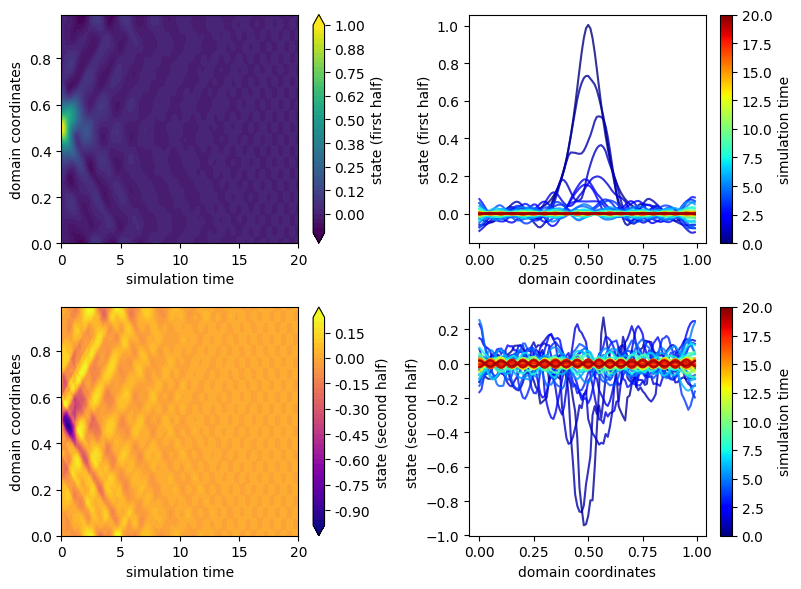

In [31]:
# Preview state trajectories before generating the large dataset
traj_idx = 1
contour = True
surface3d = False
dpi = 200

for mode in data["dataset_modes"]:
    _plot_single_from_data(data, int(traj_idx), mode=mode, contour=contour, surface3d=surface3d, dpi=dpi)


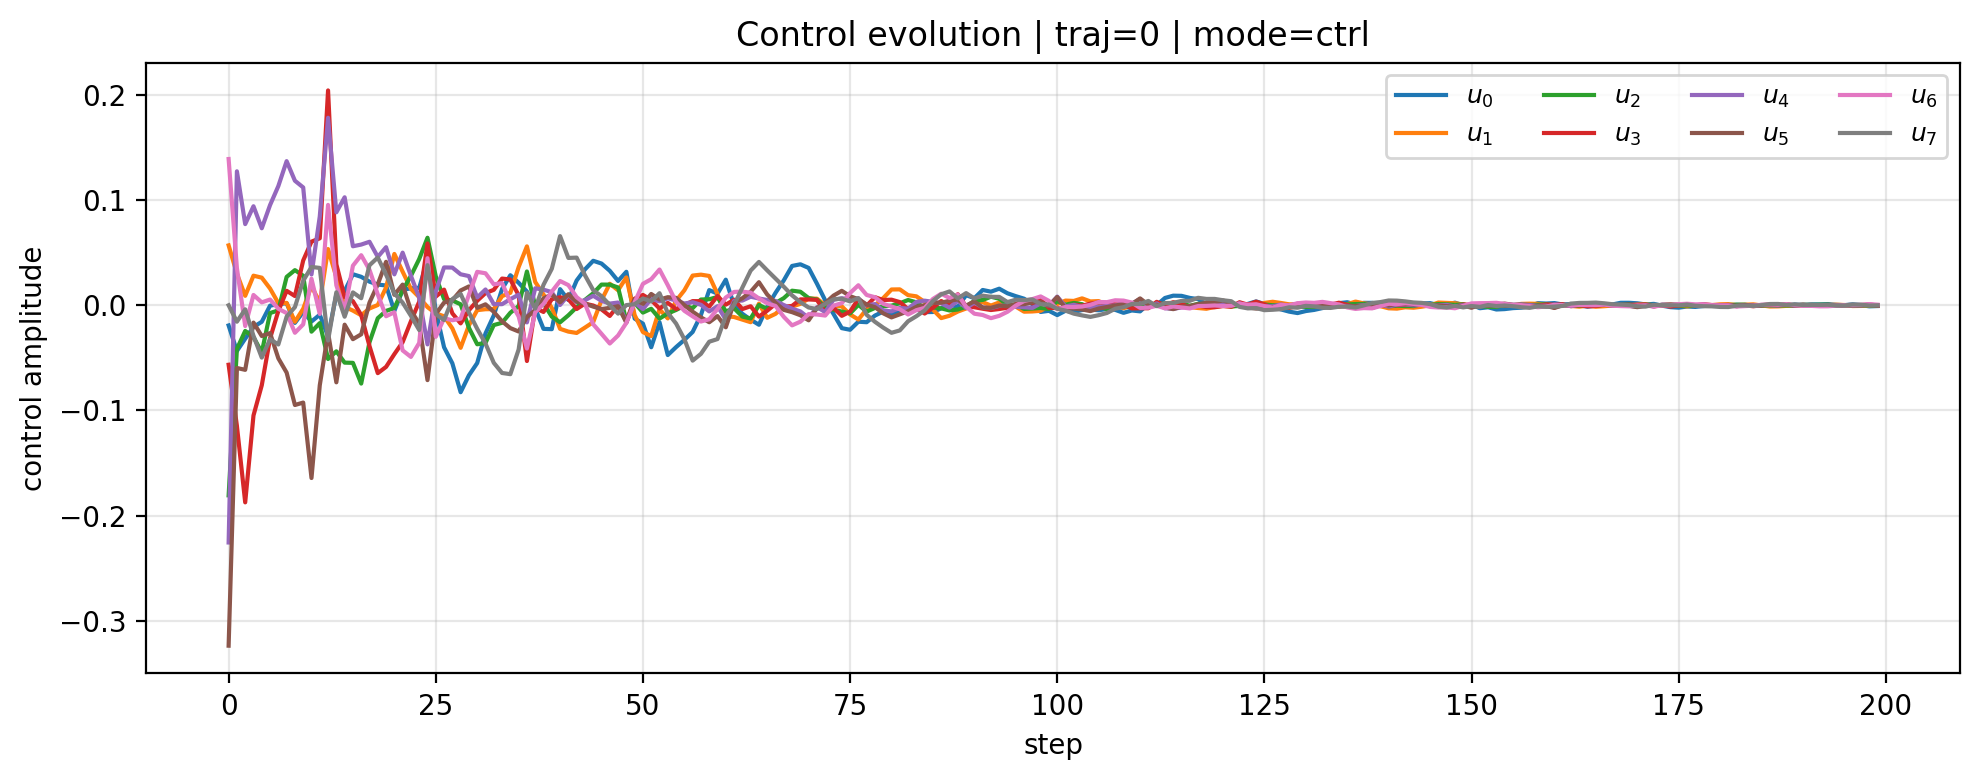

[traj=0 | mode=ctrl] U shape = (8, 200), T = 200


In [32]:
# Preview actuator trajectories before generating the large dataset
traj_idx = 0
for mode in data["dataset_modes"]:
    _plot_controls_from_data(data, traj_idx=traj_idx, mode=mode, dpi=200)


In [33]:
import json


def build_export_dataset(data, mode="ctrl", fill_nan=False):
    """Convert plotting-friendly arrays into time-major export arrays."""
    available_modes = tuple(data.get("dataset_modes", DATASET_MODES))
    if mode not in available_modes:
        raise ValueError(f"mode must be one of {available_modes}.")

    X = data["X"][mode]
    U = data["U"][mode]
    F = data["U_field"][mode]
    seeds = data.get("seeds") or {}

    ds = {
        "solutions": np.transpose(X, (0, 2, 1)),
        "init_states": data["init_states"][:, None, :].copy(),
        "controls": np.transpose(U, (0, 2, 1)),
        "controls_field": np.transpose(F, (0, 2, 1)),
        "R": data["R"][mode].copy(),
        "T": data["T"][mode].copy(),
        "env_id": data.get("env_id"),
        "ctrl_mode": data.get("ctrl_mode"),
        "dataset_modes": available_modes,
        "env_kwargs": dict(data.get("env_kwargs", {})),
        "random_signal_kwargs": dict(data.get("random_signal_kwargs", {})),
        "seeds": dict(seeds),
        "export_mode": mode,
    }

    if fill_nan:
        for key in ("solutions", "controls", "controls_field"):
            ds[key] = np.nan_to_num(ds[key])

    return ds


In [34]:
for mode in data["dataset_modes"]:
    ds = build_export_dataset(data, mode=mode)
    print(f"{mode}:")
    print(ds["solutions"].shape)      # (n_traj, n_steps+1, n_state)
    print(ds["init_states"].shape)    # (n_traj, 1, n_state)
    print(ds["controls"].shape)       # (n_traj, n_steps, n_action)
    print(ds["controls_field"].shape) # (n_traj, n_steps, n_state)
    print(ds["R"].shape, ds["T"].shape)
    print(ds["seeds"])


ctrl:
(3, 201, 200)
(3, 1, 200)
(3, 200, 8)
(3, 200, 200)
(3,) (3,)
{'init_seed': 999, 'noise_seed': 10000}


### Dataset Structure Confirmation

The dataset contains **N distinct initial states** stored in `init_states`.

For each initial state $x_0^{(k)}$, one trajectory is generated for every requested mode in `data["dataset_modes"]`.
All generated modes for the same trajectory index start from the same initial state:

$$
x_0^{(k)} = X_{\text{mode}}[k,:,0]
$$

for every `mode` in `data["dataset_modes"]`.

**Summary**

- `N` unique initial states
- one matched rollout per requested mode for each initial state
- all requested modes are aligned by trajectory index


In [35]:
def check_dataset_diversity(data, dec=10):
    N = data["init_states"].shape[0]
    modes = tuple(data.get("dataset_modes", DATASET_MODES))

    same_init_by_mode = {
        mode: np.allclose(data["init_states"], data["X"][mode][:, :, 0])
        for mode in modes
    }

    uniq_init = np.unique(np.round(data["init_states"], dec), axis=0).shape[0]

    unique_rollouts = {}
    for mode in modes:
        signatures = []
        for k in range(N):
            T = int(data["T"][mode][k])
            Xk = np.round(data["X"][mode][k, :, : T + 1], dec)
            Uk = np.round(data["U"][mode][k, :, : T], dec)
            signatures.append((Xk.tobytes(), Uk.tobytes()))
        unique_rollouts[mode] = len(set(signatures))

    print(f"N trajectories: {N}")
    for mode in modes:
        print(f"init_states == X[{mode}][:,:,0]: {same_init_by_mode[mode]}")
    print(f"unique initial states: {uniq_init}/{N}")
    for mode in modes:
        print(f"unique {mode} rollouts: {unique_rollouts[mode]}/{N}")


check_dataset_diversity(data)


N trajectories: 3
init_states == X[ctrl][:,:,0]: True
unique initial states: 3/3
unique ctrl rollouts: 3/3


In [ ]:
num_traj = 10 #2000 full number 
full_dataset_modes = DATASET_MODES  # e.g. ("zero", "ctrl") to skip random on large runs

data_full = generate_controlled_dataset(
    env_id="wave",
    n_traj=num_traj,
    ctrl_mode="lqg",
    dataset_modes=full_dataset_modes,
    init_seed=123,
    noise_seed=10_000,
    random_signal_kwargs={
        "signal_mode": "manual",
        "freq_range": (1, 3),
        "min_val": -0.5,
        "max_val": 0.5,
        "amp_range": (10, 20),
    },
    n_state=200,
    n_observation=200,
    n_action=8,
    n_steps=200,
    process_noise_cov=0,
    sensor_noise_cov=1e-8,
    verbose=True,
)


In [ ]:
mode = "ctrl"
if mode in data_full["dataset_modes"]:
    ds = build_export_dataset(data_full, mode=mode)
    np.savez_compressed(
        f"wave_dataset_{mode}_{num_traj}.npz",
        solutions=ds["solutions"],
        init_states=ds["init_states"],
        controls=ds["controls"],
        controls_field=ds["controls_field"],
        R=ds["R"],
        T=ds["T"],
        B2=data_full["B2"],
        env_id=np.array(ds["env_id"]),
        ctrl_mode=np.array(ds["ctrl_mode"]),
        export_mode=np.array(ds["export_mode"]),
        dataset_modes_json=np.array(json.dumps(list(ds["dataset_modes"]))),
        env_kwargs_json=np.array(json.dumps(ds["env_kwargs"], sort_keys=True)),
        random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"], sort_keys=True)),
        seeds_json=np.array(json.dumps(ds["seeds"], sort_keys=True)),
        total_time_sec=np.array(data_full["total_time_sec"]),
        mean_time_per_traj_sec=np.array(data_full["mean_time_per_traj_sec"]),
    )
else:
    print(f"Skipping {mode}: not generated.")


In [ ]:
mode = "zero"
if mode in data_full["dataset_modes"]:
    ds = build_export_dataset(data_full, mode=mode)
    np.savez_compressed(
        f"wave_dataset_{mode}_{num_traj}.npz",
        solutions=ds["solutions"],
        init_states=ds["init_states"],
        controls=ds["controls"],
        controls_field=ds["controls_field"],
        R=ds["R"],
        T=ds["T"],
        B2=data_full["B2"],
        env_id=np.array(ds["env_id"]),
        ctrl_mode=np.array(ds["ctrl_mode"]),
        export_mode=np.array(ds["export_mode"]),
        dataset_modes_json=np.array(json.dumps(list(ds["dataset_modes"]))),
        env_kwargs_json=np.array(json.dumps(ds["env_kwargs"], sort_keys=True)),
        random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"], sort_keys=True)),
        seeds_json=np.array(json.dumps(ds["seeds"], sort_keys=True)),
        total_time_sec=np.array(data_full["total_time_sec"]),
        mean_time_per_traj_sec=np.array(data_full["mean_time_per_traj_sec"]),
    )
else:
    print(f"Skipping {mode}: not generated.")


In [ ]:
mode = "random"
if mode in data_full["dataset_modes"]:
    ds = build_export_dataset(data_full, mode=mode)
    np.savez_compressed(
        f"wave_dataset_{mode}_{num_traj}.npz",
        solutions=ds["solutions"],
        init_states=ds["init_states"],
        controls=ds["controls"],
        controls_field=ds["controls_field"],
        R=ds["R"],
        T=ds["T"],
        B2=data_full["B2"],
        env_id=np.array(ds["env_id"]),
        ctrl_mode=np.array(ds["ctrl_mode"]),
        export_mode=np.array(ds["export_mode"]),
        dataset_modes_json=np.array(json.dumps(list(ds["dataset_modes"]))),
        env_kwargs_json=np.array(json.dumps(ds["env_kwargs"], sort_keys=True)),
        random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"], sort_keys=True)),
        seeds_json=np.array(json.dumps(ds["seeds"], sort_keys=True)),
        total_time_sec=np.array(data_full["total_time_sec"]),
        mean_time_per_traj_sec=np.array(data_full["mean_time_per_traj_sec"]),
    )
else:
    print(f"Skipping {mode}: not generated.")


Sanity checks for created data in `data_*` folders

In [42]:
# Load one exported dataset and inspect it
npz_path = "data_test/wave_dataset_random_10.npz"   # change as needed
traj_idx = 3

ds_npz = np.load(npz_path, allow_pickle=True)

print("Dataset keys:")
print(list(ds_npz.keys()))

solutions = ds_npz["solutions"]         # (N, T+1, n_state)
controls = ds_npz["controls"]           # (N, T, n_action)
controls_field = ds_npz["controls_field"]  # (N, T, n_state)
init_states = ds_npz["init_states"]     # (N, 1, n_state)
T = ds_npz["T"]                         # (N,)

print("solutions:", solutions.shape)
print("controls:", controls.shape)
print("controls_field:", controls_field.shape)
print("init_states:", init_states.shape)
print("T:", T.shape)

T_idx = int(T[traj_idx])

X = solutions[traj_idx, : T_idx + 1, :]     # (T+1, n_state)
U = controls[traj_idx, : T_idx, :]          # (T, n_action)

print(f"\ntraj_idx={traj_idx}")
print("X:", X.shape)
print("U:", U.shape)
print("init == first state:", np.allclose(init_states[traj_idx, 0], X[0]))


Dataset keys:
['solutions', 'init_states', 'controls', 'controls_field', 'R', 'T', 'B2', 'env_id', 'ctrl_mode', 'export_mode', 'dataset_modes_json', 'env_kwargs_json', 'random_signal_kwargs_json', 'seeds_json', 'total_time_sec', 'mean_time_per_traj_sec']
solutions: (10, 201, 200)
controls: (10, 200, 8)
controls_field: (10, 200, 200)
init_states: (10, 1, 200)
T: (10,)

traj_idx=3
X: (201, 200)
U: (200, 8)
init == first state: True


In [45]:
print(ds_npz["env_kwargs_json"])
print(ds_npz["export_mode"])
print(ds_npz["seeds_json"])

{"n_action": 8, "n_observation": 200, "n_state": 200, "n_steps": 200, "process_noise_cov": 0.0, "sensor_noise_cov": 1e-08}
random
{"init_seed": 123, "noise_seed": 10000}


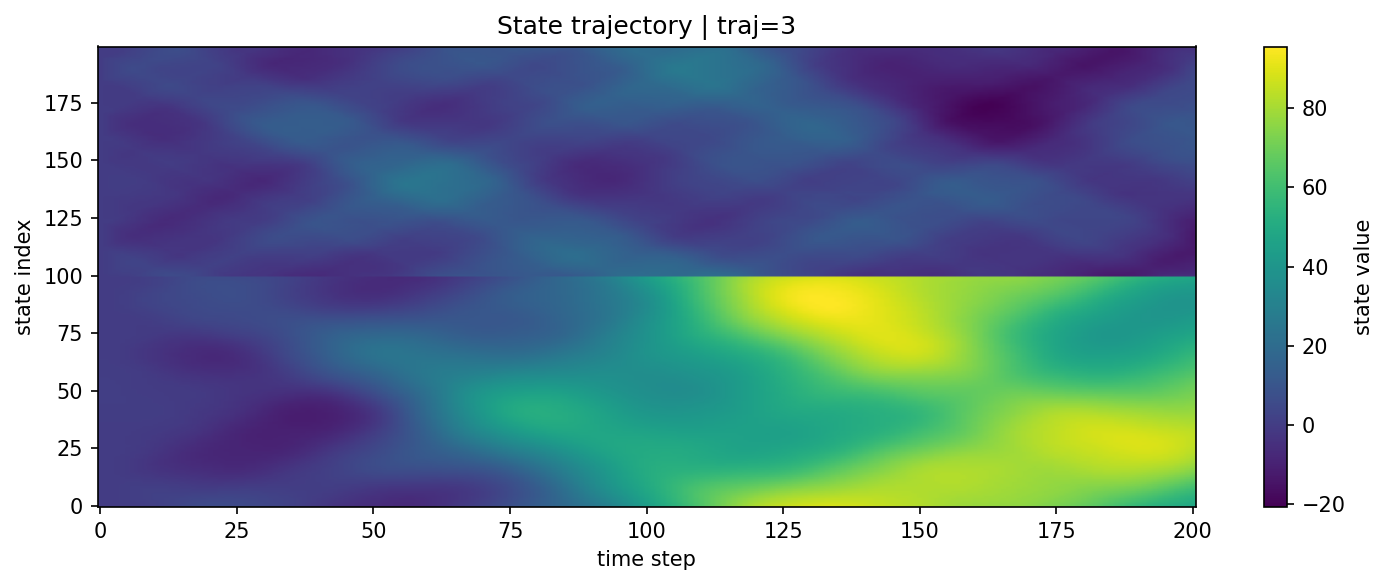

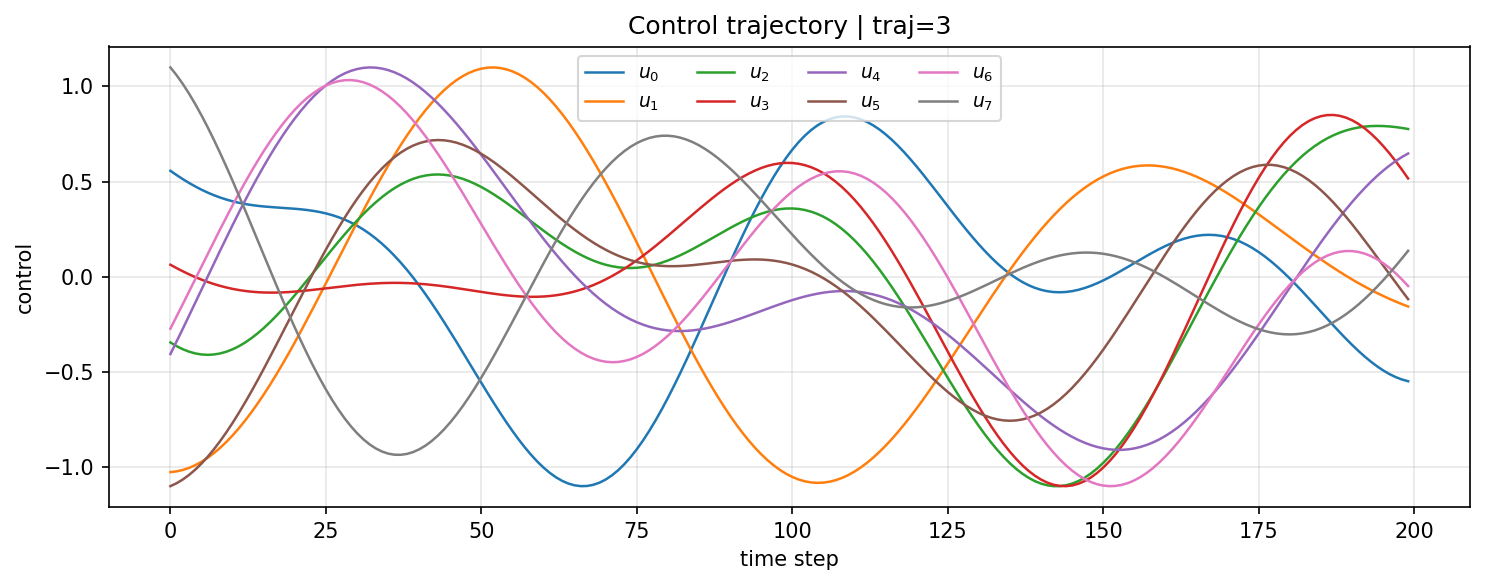

In [43]:
# State heatmap: time x state-index
plt.figure(figsize=(10, 4), dpi=150)
plt.imshow(X.T, aspect="auto", origin="lower")
plt.colorbar(label="state value")
plt.xlabel("time step")
plt.ylabel("state index")
plt.title(f"State trajectory | traj={traj_idx}")
plt.tight_layout()
plt.show()

# Control trajectories
plt.figure(figsize=(10, 4), dpi=150)
for a in range(U.shape[1]):
    plt.plot(U[:, a], label=fr"$u_{a}$", linewidth=1.2)
plt.xlabel("time step")
plt.ylabel("control")
plt.title(f"Control trajectory | traj={traj_idx}")
plt.grid(True, alpha=0.3)
plt.legend(ncol=min(4, U.shape[1]), fontsize=9)
plt.tight_layout()
plt.show()


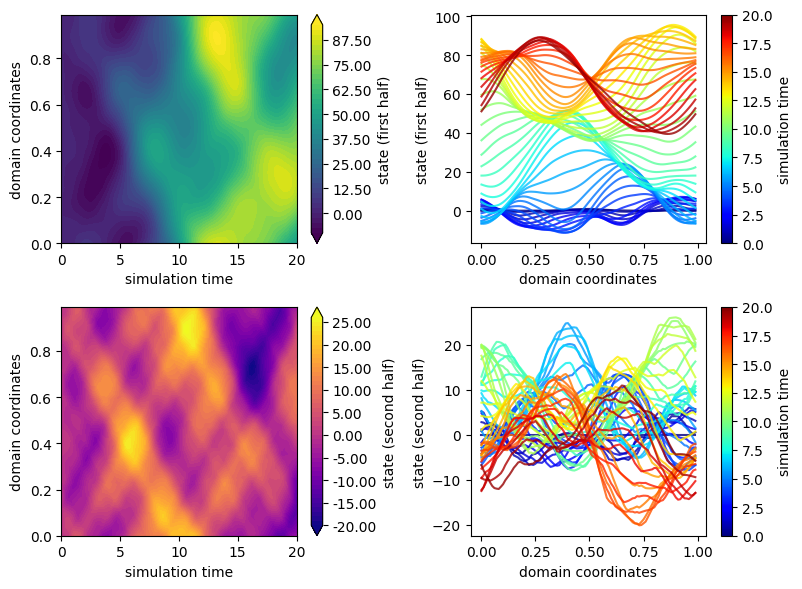

In [44]:
env_kwargs = json.loads(str(ds_npz["env_kwargs_json"]))
env = gym.make(str(ds_npz["env_id"]), **env_kwargs)

env.n_steps = T_idx
env.state_traj = X.T   # plotting helpers expect (n_state, T+1)

with tempfile.TemporaryDirectory() as tmpdir:
    if env.id in ["wave", "schrodinger"]:
        _plot_coupled_pde(env, save_dir=tmpdir, display=True, contour=True, surface3d=False, dpi=200)
    else:
        _plot_pde(env, save_dir=tmpdir, display=True, contour=True, surface3d=False, dpi=200)
